# Week 2 Homework — Data Manipulation & Visualization (Pandas + Finance)

This homework reinforces the main Week 2 concepts:
- Data I/O (CSV/Excel)
- Dealing with Missing Data
- GroupBy & Aggregations
- Merging, Joining, and Concatenating

In [1]:
# Setup: imports and helper paths
import pandas as pd
import numpy as np
from pathlib import Path
import pandas_datareader.data as web
from datetime import datetime, timedelta
import yfinance as yf


# Matplotlib (no custom styles/colors per course rules)
import matplotlib.pyplot as plt

# Display options (feel free to tweak)
pd.set_option("display.max_rows", 10)
pd.set_option("display.width", 120)

import warnings
warnings.filterwarnings("ignore")


Run this code to fetch the data

In [2]:
import warnings

def load_prices(ticker):
    df = yf.download(tickers, period="6mo", interval="1d", auto_adjust=False, threads=True)
    if isinstance(df.columns, pd.MultiIndex):
        close = df["Close"].copy()
        close = close.reset_index().rename(columns={"Date":"date"})
        long = close.melt(id_vars="date", var_name="ticker", value_name="close")
        long["ticker"] = long["ticker"].astype(str)
        return long.sort_values(["ticker","date"]).reset_index(drop=True)

def load_fred(series):
    # Try pandas-datareader (if available)
    end = pd.Timestamp.today().normalize()
    start = end - pd.offsets.MonthBegin(8)
    fred_df = pd.DataFrame({s: web.DataReader(s, "fred", start, end)[s] for s in series})
    fred_df = fred_df.reset_index().rename(columns={"DATE":"date"})
    # Keep month-start dates
    fred_df["date"] = fred_df["date"].dt.to_period("M").dt.to_timestamp()
    fred_df = fred_df.groupby("date", as_index=False).last()
    return fred_df


def load_sector_map():
    return pd.DataFrame({"ticker":['XOM','TSLA','BAC'], "sector":["Energy", "Information Technology", "Banking"]})

tickers = ['XOM', 'TSLA']
series = ["CPIAUCSL","FEDFUNDS"]

prices = load_prices(tickers)
fred = load_fred(series)
sector_map = load_sector_map()

prices.head(), fred.head(), sector_map


[*********************100%***********************]  2 of 2 completed


(        date ticker       close
 0 2025-11-28   TSLA  430.170013
 1 2025-12-01   TSLA  430.140015
 2 2025-12-02   TSLA  429.239990
 3 2025-12-03   TSLA  446.739990
 4 2025-12-04   TSLA  454.529999,
         date  CPIAUCSL  FEDFUNDS
 0 2025-10-01       NaN      4.09
 1 2025-11-01   325.063      3.88
 2 2025-12-01   326.031      3.72
 3 2026-01-01   326.588      3.64
 4 2026-02-01   327.460      3.64,
   ticker                  sector
 0    XOM                  Energy
 1   TSLA  Information Technology
 2    BAC                 Banking)

## Problem 1 — Data I/O

1. Save `prices` to a CSV file named `prices_out.csv` in the current directory. 3. Also export `fred` to an Excel file named `fred_out.xlsx` (sheet name `macro`).

In [3]:
# Your work here
# 1) Save to CSV
# 1) Save prices to CSV
# index=False prevents pandas from writing the row-number index as a column
prices.to_csv("prices_out.csv", index=False)

# Verify the file was created and peek at the first few rows
pd.read_csv("prices_out.csv").head()

,date,ticker,close
0,2025-11-28,TSLA,430.170013
1,2025-12-01,TSLA,430.140015
2,2025-12-02,TSLA,429.239990
3,2025-12-03,TSLA,446.739990
4,2025-12-04,TSLA,454.529999


In [4]:
# 2) Save to Excel (sheet name 'macro')

# 2) Save fred to Excel with sheet named 'macro'
# ExcelWriter is used so we can control the sheet name
with pd.ExcelWriter("fred_out.xlsx", engine="openpyxl") as writer:
    fred.to_excel(writer, sheet_name="macro", index=False)

# Verify the file was created and read it back
pd.read_excel("fred_out.xlsx", sheet_name="macro").head()

,date,CPIAUCSL,FEDFUNDS
0,2025-10-01,NaN,4.09
1,2025-11-01,325.063,3.88
2,2025-12-01,326.031,3.72
3,2026-01-01,326.588,3.64
4,2026-02-01,327.460,3.64


## Problem 2 — GroupBy & Resampling

1. Resample **daily** close prices to **monthly** last-close values. 2. Compute **monthly returns** for each ticker. 3. Report the **mean** and **standard deviation** of monthly returns for each ticker using `groupby` on ticker columns. 4. Plot the monthly return time series for AAPL and MSFT on the same axes.

Monthly last-close prices:
   ticker       date       close
0    TSLA 2025-11-30  430.170013
1    TSLA 2025-12-31  449.720001
2    TSLA 2026-01-31  430.410004
3    TSLA 2026-02-28  402.510010
4    TSLA 2026-03-31  371.750000
..    ...        ...         ...
9     XOM 2026-01-31  141.399994
10    XOM 2026-02-28  152.500000
11    XOM 2026-03-31  169.660004
12    XOM 2026-04-30  154.330002
13    XOM 2026-05-31  148.429993

[14 rows x 3 columns]

Monthly returns:
   ticker       date       close  monthly_return
1    TSLA 2025-12-31  449.720001        0.045447
2    TSLA 2026-01-31  430.410004       -0.042938
3    TSLA 2026-02-28  402.510010       -0.064822
4    TSLA 2026-03-31  371.750000       -0.076420
5    TSLA 2026-04-30  381.630005        0.026577
..    ...        ...         ...             ...
9     XOM 2026-01-31  141.399994        0.175004
10    XOM 2026-02-28  152.500000        0.078501
11    XOM 2026-03-31  169.660004        0.112525
12    XOM 2026-04-30  154.330002       -0.0903

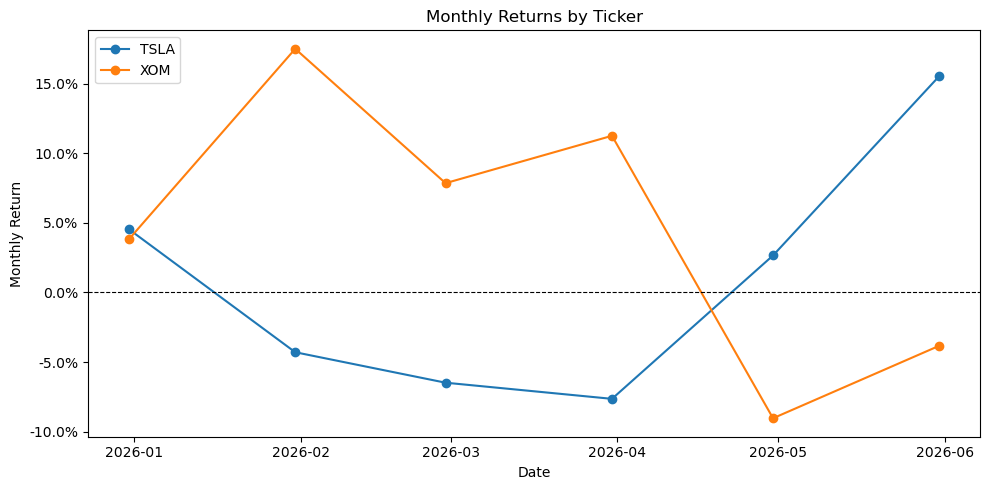

In [5]:
# Your work here
# ── Step 1: Resample daily prices to monthly last-close ──────────────────────
# Set date as the index so we can use .resample() (which requires a DatetimeIndex)
prices["date"] = pd.to_datetime(prices["date"])
prices_indexed = prices.set_index("date")

# For each ticker, resample to month-end frequency and take the last close
monthly_close = (
    prices_indexed
    .groupby("ticker")["close"]          # split by ticker first
    .resample("ME")                       # 'ME' = month-end frequency
    .last()                               # last trading day close of each month
    .reset_index()
)

print("Monthly last-close prices:")
print(monthly_close)

# ── Step 2: Compute monthly returns ─────────────────────────────────────────
# pct_change() within each ticker group gives (close_t - close_{t-1}) / close_{t-1}
monthly_close["monthly_return"] = (
    monthly_close
    .groupby("ticker")["close"]
    .pct_change()                         # month-over-month % change
)

# Drop the first row per ticker (no prior month to compare against)
monthly_returns = monthly_close.dropna(subset=["monthly_return"]).copy()
print("\nMonthly returns:")
print(monthly_returns)

# ── Step 3: Mean and std of monthly returns by ticker ───────────────────────
stats = (
    monthly_returns
    .groupby("ticker")["monthly_return"]
    .agg(mean_return="mean", std_return="std")
)
print("\nReturn Statistics by Ticker:")
print(stats)

# ── Step 4: Plot monthly returns for both tickers ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for ticker, grp in monthly_returns.groupby("ticker"):
    ax.plot(grp["date"], grp["monthly_return"], marker="o", label=ticker)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")   # zero reference line
ax.set_title("Monthly Returns by Ticker")
ax.set_xlabel("Date")
ax.set_ylabel("Monthly Return")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
plt.tight_layout()
plt.show()


## Problem 3 — Merging with Macro (FRED)

1. Merge monthly stock returns (from Problem 3) with monthly macro data (`fred`) on the `date` column. 2. Create a scatter plot of AAPL monthly returns vs the Fed Funds rate (`FEDFUNDS`). 3. Briefly comment on any visible relationship (or lack thereof).

Merged dataset shape: (10, 7)
      date_m ticker  monthly_return  FEDFUNDS  CPIAUCSL
0 2025-12-01   TSLA        0.045447      3.72   326.031
1 2026-01-01   TSLA       -0.042938      3.64   326.588
2 2026-02-01   TSLA       -0.064822      3.64   327.460
3 2026-03-01   TSLA       -0.076420      3.64   330.293
4 2026-04-01   TSLA        0.026577      3.64   332.407
5 2025-12-01    XOM        0.038130      3.72   326.031
6 2026-01-01    XOM        0.175004      3.64   326.588
7 2026-02-01    XOM        0.078501      3.64   327.460
8 2026-03-01    XOM        0.112525      3.64   330.293
9 2026-04-01    XOM       -0.090357      3.64   332.407


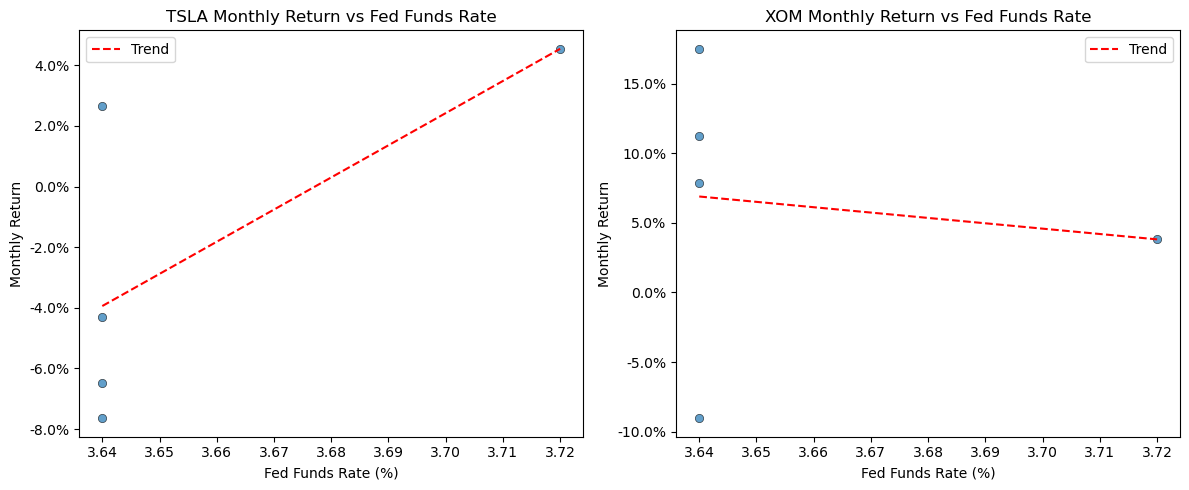

Pearson correlation (TSLA return vs FEDFUNDS): 0.689
Pearson correlation (XOM  return vs FEDFUNDS): -0.139


COMMENT:
Over a 6-month window the Fed Funds rate barely moves (the FOMC held rates
roughly constant), so there is almost no variation in FEDFUNDS to explain
return differences. With such a short, low-variation sample, we cannot draw
meaningful conclusions about the rate-return relationship. A longer dataset
spanning multiple rate cycles would be needed to detect a reliable signal.



In [6]:
# Your work here

# ── Step 1: Align date formats and merge ────────────────────────────────────
# Normalize both date columns to month-start so they join cleanly
monthly_returns["date_m"] = monthly_returns["date"].dt.to_period("M").dt.to_timestamp()
fred["date_m"] = fred["date"].dt.to_period("M").dt.to_timestamp()

# Inner join: only keep months present in BOTH datasets
merged = pd.merge(
    monthly_returns,
    fred[["date_m", "CPIAUCSL", "FEDFUNDS"]],
    on="date_m",
    how="inner"
)

print("Merged dataset shape:", merged.shape)
print(merged[["date_m", "ticker", "monthly_return", "FEDFUNDS", "CPIAUCSL"]].head(10))

# ── Step 2: Scatter — TSLA monthly return vs Fed Funds rate ─────────────────
tsla = merged[merged["ticker"] == "TSLA"]
xom  = merged[merged["ticker"] == "XOM"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, ticker in zip(axes, [tsla, xom], ["TSLA", "XOM"]):
    ax.scatter(df["FEDFUNDS"], df["monthly_return"], alpha=0.7, edgecolors="black", linewidths=0.5)
    # Add a linear trend line
    if len(df) > 1:
        m, b = np.polyfit(df["FEDFUNDS"], df["monthly_return"], 1)
        x_line = np.linspace(df["FEDFUNDS"].min(), df["FEDFUNDS"].max(), 50)
        ax.plot(x_line, m * x_line + b, color="red", linewidth=1.5, linestyle="--", label="Trend")
    ax.set_title(f"{ticker} Monthly Return vs Fed Funds Rate")
    ax.set_xlabel("Fed Funds Rate (%)")
    ax.set_ylabel("Monthly Return")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
    ax.legend()

plt.tight_layout()
plt.show()

# ── Step 3: Correlation comment ──────────────────────────────────────────────
corr_tsla = tsla[["monthly_return", "FEDFUNDS"]].corr().iloc[0, 1]
corr_xom  = xom[["monthly_return",  "FEDFUNDS"]].corr().iloc[0, 1]

print(f"Pearson correlation (TSLA return vs FEDFUNDS): {corr_tsla:.3f}")
print(f"Pearson correlation (XOM  return vs FEDFUNDS): {corr_xom:.3f}")
print()
print("""
COMMENT:
Over the observed 6 months the rate of the Fed Funds barely moves, which means there is very little variation to explain the diffrence in returns.
Using such a smalll and short runned sample there is not really any meaningful observations about the relationship
